In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import sklearn
from pathlib import Path
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, GridSearchCV, LearningCurveDisplay, RepeatedStratifiedKFold, StratifiedKFold, ValidationCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

In [2]:
PROJ_PATH = Path(os.getcwd()).parent
DATA_PATH = PROJ_PATH / 'Data'

In [3]:
train = pd.read_csv(DATA_PATH / 'train.csv')
X_train = train.copy().iloc[:, :-1]
y_train = train.copy()['UPSET']

test = pd.read_csv(DATA_PATH / 'test.csv')
X_test = test.copy().iloc[:, :-1]
y_test = test.copy()['UPSET']

In [4]:
print(f"Percentage of samples in training set that were an upset: {round(np.mean(y_train)*100, 2)}%")
print(f"Percentage of samples in test set that were an upset: {round(np.mean(y_test)*100, 2)}%")

Percentage of samples in training set that were an upset: 29.91%
Percentage of samples in test set that were an upset: 29.68%


# Model Selection

In [5]:
explore_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=0
)

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=2
)

final_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=3
)


def nested_cross_validation(estimator, X, y, param_grid, outer_cv, inner_cv, **grid_search_args):
    outer_cv_results = []
    X_orig = np.array(X)
    y_orig = np.array(y)
    for fold_idx, (train_idx, val_idx) in enumerate(outer_cv.split(X_orig, y_orig), start=1):
        X_train, X_val = X_orig[train_idx], X_orig[val_idx]
        y_train, y_val = y_orig[train_idx], y_orig[val_idx]

        grid = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            cv=inner_cv,
            **grid_search_args
        )

        grid.fit(X_train, y_train)

        # Evaluate on the outer test set
        y_val_pred = grid.predict(X_val)
        outer_score = accuracy_score(y_val, y_val_pred)  # TODO: Hardcoded scoring function

        # Store everything we care about
        outer_cv_results.append({
            "fold": fold_idx,
            "best_params": grid.best_params_,
            "best_inner_score": grid.best_score_,
            "outer_test_score": outer_score,
            "inner_cv_results": grid.cv_results_
        })
    
    return {"scores": np.array([fold['outer_test_score'] for fold in outer_cv_results]), "outer_cv_results": outer_cv_results}

## Baseline Model

In [6]:
baseline_model = DummyClassifier(strategy="constant", constant=0)

baseline_model_acc = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=outer_cv,
    scoring="accuracy"
)

print(f"Baseline CV Accuracy: {baseline_model_acc.mean():.5f} +/- {baseline_model_acc.std():.5f}")

Baseline CV Accuracy: 0.69472 +/- 0.00285


## Logistic Regression Model

In [7]:
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=1000
    ))
])

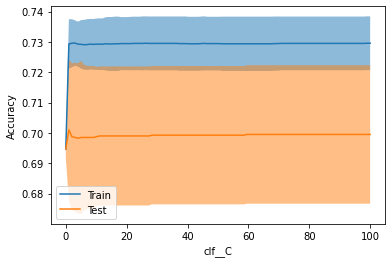

In [8]:
ValidationCurveDisplay.from_estimator(lr_model, X_train, y_train, param_name='clf__C',
                                      param_range=np.linspace(1e-5, 100, 100), cv=explore_cv, scoring='accuracy',
                                      n_jobs=-1)

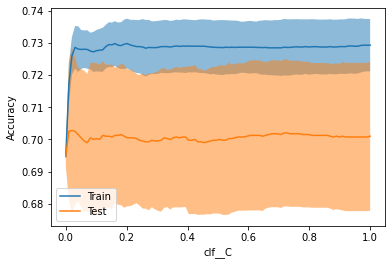

In [9]:
ValidationCurveDisplay.from_estimator(lr_model, X_train, y_train, param_name='clf__C',
                                      param_range=np.linspace(1e-5, 1, 100), cv=explore_cv, scoring='accuracy',
                                      n_jobs=-1)

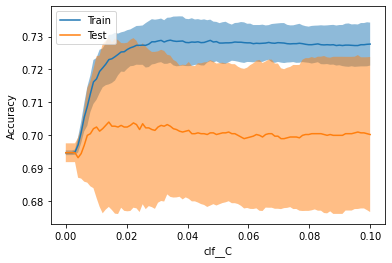

In [10]:
ValidationCurveDisplay.from_estimator(lr_model, X_train, y_train, param_name='clf__C',
                                      param_range=np.linspace(1e-5, 0.1, 100), cv=explore_cv, scoring='accuracy',
                                      n_jobs=-1)

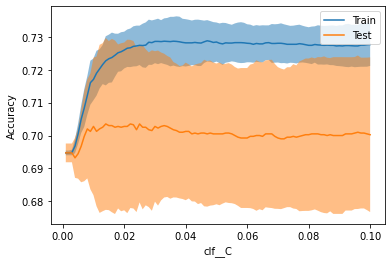

In [11]:
ValidationCurveDisplay.from_estimator(lr_model, X_train, y_train, param_name='clf__C',
                                      param_range=np.linspace(1e-3, 0.1, 100), cv=explore_cv, scoring='accuracy',
                                      n_jobs=-1)

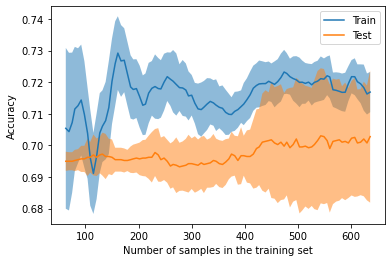

In [12]:
lr_lc_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        C=0.01,
        penalty="l2",
        solver="lbfgs",
        max_iter=1000
    ))
])

LearningCurveDisplay.from_estimator(lr_lc_model, X_train, y_train, train_sizes=np.linspace(0.1, 1.0, 100),
                                    cv=explore_cv, scoring='accuracy', n_jobs=-1)

In [13]:
param_grid = {'clf__C': [0.001, 0.01, 0.1]}
lr_nested_acc = nested_cross_validation(
    lr_model,
    X_train,
    y_train,
    param_grid,
    outer_cv,
    inner_cv,
    scoring='accuracy',
    refit=True,
    return_train_score=True,
    n_jobs=-1
)


print(f"Logistic Regression CV Accuracy: {lr_nested_acc['scores'].mean():.5f} +/- {lr_nested_acc['scores'].std():.5f}")

Logistic Regression CV Accuracy: 0.69726 +/- 0.01163


In [14]:
pd.DataFrame(lr_nested_acc['outer_cv_results'])

,fold,best_params,best_inner_score,outer_test_score,inner_cv_results
0,1,{'clf__C': 0.01},0.707566,0.681250,"{'mean_fit_time': [0.005253839492797852, 0.006..."
1,2,{'clf__C': 0.01},0.698524,0.685535,"{'mean_fit_time': [0.0033454418182373045, 0.00..."
2,3,{'clf__C': 0.01},0.700148,0.710692,"{'mean_fit_time': [0.003654146194458008, 0.004..."
3,4,{'clf__C': 0.01},0.700197,0.704403,"{'mean_fit_time': [0.0038311004638671873, 0.00..."
4,5,{'clf__C': 0.1},0.704798,0.704403,"{'mean_fit_time': [0.0040895938873291016, 0.00..."


## Gradient Boosting Model

In [15]:
xgb_model = XGBClassifier(
    max_depth=1,
    n_estimators=10,
    learning_rate=0.3,
    colsample_bytree=0.7,
    random_state=123
)

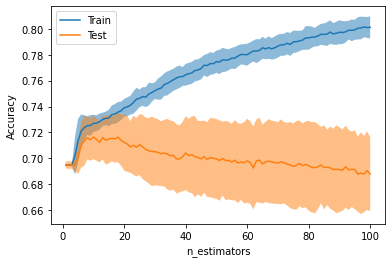

In [16]:
ValidationCurveDisplay.from_estimator(xgb_model, X_train, y_train, param_name='n_estimators',
                                      param_range=range(1, 101), cv=explore_cv, scoring='accuracy',
                                      n_jobs=1)

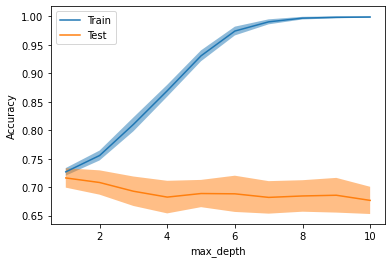

In [17]:
ValidationCurveDisplay.from_estimator(xgb_model, X_train, y_train, param_name='max_depth',
                                      param_range=range(1, 11), cv=explore_cv, scoring='accuracy',
                                      n_jobs=1)

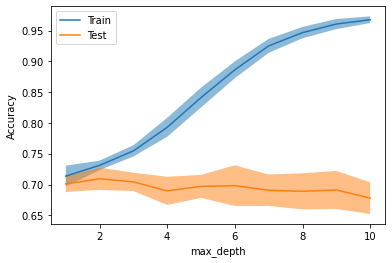

In [18]:
xgb_alt_model = XGBClassifier(
    max_depth=1,
    n_estimators=5,
    learning_rate=0.3,
    colsample_bytree=0.7,
    random_state=123
)

ValidationCurveDisplay.from_estimator(xgb_alt_model, X_train, y_train, param_name='max_depth',
                                      param_range=range(1, 11), cv=explore_cv, scoring='accuracy',
                                      n_jobs=1)

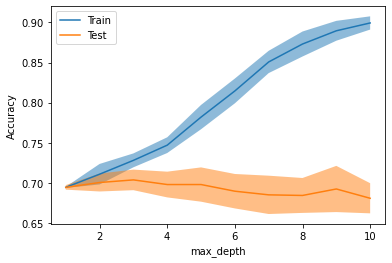

In [19]:
xgb_alt_model = XGBClassifier(
    max_depth=1,
    n_estimators=3,
    learning_rate=0.3,
    colsample_bytree=0.7,
    random_state=123
)

ValidationCurveDisplay.from_estimator(xgb_alt_model, X_train, y_train, param_name='max_depth',
                                      param_range=range(1, 11), cv=explore_cv, scoring='accuracy',
                                      n_jobs=1)

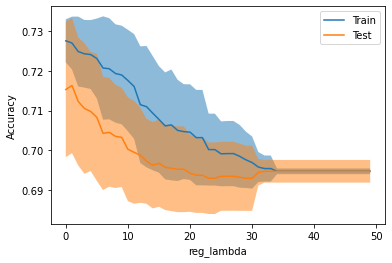

In [20]:
ValidationCurveDisplay.from_estimator(xgb_model, X_train, y_train, param_name='reg_lambda',
                                      param_range=np.arange(0, 50), cv=explore_cv, scoring='accuracy',
                                      n_jobs=1)

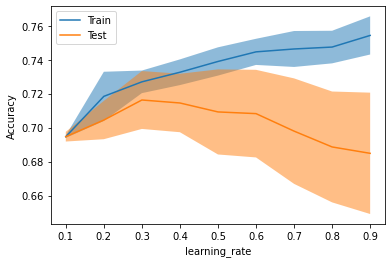

In [21]:
ValidationCurveDisplay.from_estimator(xgb_model, X_train, y_train, param_name='learning_rate',
                                      param_range=np.arange(0.1, 1, 0.1), cv=explore_cv, scoring='accuracy',
                                      n_jobs=1)

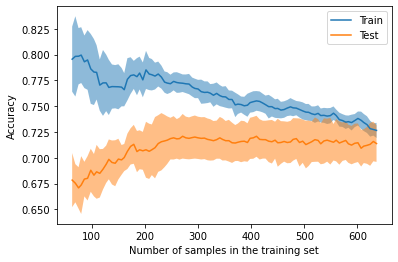

In [22]:
LearningCurveDisplay.from_estimator(xgb_model, X_train, y_train, train_sizes=np.linspace(0.1, 1.0, 100),
                                    cv=explore_cv, scoring='accuracy', n_jobs=1)

In [23]:
param_grid = {
    'max_depth': [1, 2, 3],
    'n_estimators': range(5, 16),
    'reg_lambda': np.arange(0, 0.5, 0.1),
    'learning_rate': np.arange(0, 0.5, 0.1)
}
xgb_nested_acc = nested_cross_validation(
    xgb_model,
    X_train,
    y_train,
    param_grid,
    outer_cv,
    inner_cv,
    scoring='accuracy',
    refit=True,
    return_train_score=True,
    n_jobs=1
)


print(f"XGBoost CV Accuracy: {xgb_nested_acc['scores'].mean():.5f} +/- {xgb_nested_acc['scores'].std():.5f}")

XGBoost CV Accuracy: 0.70603 +/- 0.00731


In [24]:
pd.DataFrame(xgb_nested_acc['outer_cv_results'])

,fold,best_params,best_inner_score,outer_test_score,inner_cv_results
0,1,"{'learning_rate': 0.4, 'max_depth': 2, 'n_esti...",0.726464,0.706250,"{'mean_fit_time': [0.007547760009765625, 0.007..."
1,2,"{'learning_rate': 0.2, 'max_depth': 2, 'n_esti...",0.722084,0.698113,"{'mean_fit_time': [0.0035526275634765623, 0.00..."
2,3,"{'learning_rate': 0.2, 'max_depth': 3, 'n_esti...",0.720571,0.710692,"{'mean_fit_time': [0.0034935474395751953, 0.00..."
3,4,"{'learning_rate': 0.2, 'max_depth': 3, 'n_esti...",0.719021,0.698113,"{'mean_fit_time': [0.0035557270050048826, 0.00..."
4,5,"{'learning_rate': 0.2, 'max_depth': 1, 'n_esti...",0.707997,0.716981,"{'mean_fit_time': [0.003478240966796875, 0.003..."


In [26]:
for fold, param_config in enumerate(pd.DataFrame(xgb_nested_acc['outer_cv_results'])['best_params']):
    print(fold)
    print(param_config)

0
{'learning_rate': 0.4, 'max_depth': 2, 'n_estimators': 15, 'reg_lambda': 0.30000000000000004}
1
{'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 7, 'reg_lambda': 0.2}
2
{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 13, 'reg_lambda': 0.2}
3
{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 6, 'reg_lambda': 0.4}
4
{'learning_rate': 0.2, 'max_depth': 1, 'n_estimators': 14, 'reg_lambda': 0.1}


## Results
Model | Mean Accuracy | Std Dev Accuracy | Lower Bound | Upper Bound
----- | ------------- | ---------------- | ----------- | -----------
Baseline | 0.69472 | 0.00285 | 0.69187 | 0.69757
Logistic Regression | 0.69726 | 0.01163 | 0.68563 | 0.70889
XGBoost | 0.70603 | 0.00731 | 0.69872 | 0.71334

# Fit & Evaluate Final Models

In [6]:
baseline_model = DummyClassifier(strategy="constant", constant=0)
baseline_model.fit(X_train, y_train)

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        C=0.01
    ))
])
lr_model.fit(X_train, y_train)

xgb_param_grid = {
    'max_depth': [1, 2, 3],
    'n_estimators': range(5, 16),
    'reg_lambda': [0.001, 0.01, 0.1, 0.2, 0.3, 0.4]
}
xgb_grid = GridSearchCV(
    estimator=XGBClassifier(learning_rate=0.2, colsample_bytree=0.7, random_state=123),
    param_grid=xgb_param_grid,
    cv=final_cv,
    scoring='accuracy',
    refit=True,
    return_train_score=True,
    n_jobs=1
)
xgb_grid.fit(X_train, y_train)
xgb_model = xgb_grid.best_estimator_

print(xgb_grid.best_params_)
print(xgb_grid.best_score_)

{'max_depth': 3, 'n_estimators': 6, 'reg_lambda': 0.3}
0.7174939088061261


In [7]:
print("Baseline Model", "-" * 14, sep="\n")
print(f"Train Acc:\t{accuracy_score(y_train, baseline_model.predict(X_train)) * 100}%",
      f"Test Acc:\t{accuracy_score(y_test, baseline_model.predict(X_test)) * 100}%", sep="\t\t")
print(f"Train F1:\t{f1_score(y_train, baseline_model.predict(X_train)) * 100}%",
      f"Test F1:\t{f1_score(y_test, baseline_model.predict(X_test)) * 100}%", sep="\t\t")
print(f"Train Pre:\t{precision_score(y_train, baseline_model.predict(X_train)) * 100}%",
      f"Test Pre:\t{precision_score(y_test, baseline_model.predict(X_test)) * 100}%", sep="\t\t")
print(f"Train Rec:\t{recall_score(y_train, baseline_model.predict(X_train)) * 100}%",
      f"Test Rec:\t{recall_score(y_test, baseline_model.predict(X_test)) * 100}%", sep="\t\t", end="\n\n")

print("Logistic Regression Model", "-" * 25, sep="\n")
print(f"Train Acc:\t{accuracy_score(y_train, lr_model.predict(X_train)) * 100}%",
      f"Test Acc:\t{accuracy_score(y_test, lr_model.predict(X_test)) * 100}%", sep="\t\t")
print(f"Train F1:\t{f1_score(y_train, lr_model.predict(X_train)) * 100}%",
      f"Test F1:\t{f1_score(y_test, lr_model.predict(X_test)) * 100}%", sep="\t\t")
print(f"Train Pre:\t{precision_score(y_train, lr_model.predict(X_train)) * 100}%",
      f"Test Pre:\t{precision_score(y_test, lr_model.predict(X_test)) * 100}%", sep="\t\t")
print(f"Train Rec:\t{recall_score(y_train, lr_model.predict(X_train)) * 100}%",
      f"Test Rec:\t{recall_score(y_test, lr_model.predict(X_test)) * 100}%", sep="\t\t", end="\n\n")

print("XGBoost Model", "-" * 13, sep="\n")
print(f"Train Acc:\t{accuracy_score(y_train, xgb_model.predict(X_train)) * 100}%",
      f"Test Acc:\t{accuracy_score(y_test, xgb_model.predict(X_test)) * 100}%", sep="\t\t")
print(f"Train F1:\t{f1_score(y_train, xgb_model.predict(X_train)) * 100}%",
      f"Test F1:\t{f1_score(y_test, xgb_model.predict(X_test)) * 100}%", sep="\t\t")
print(f"Train Pre:\t{precision_score(y_train, xgb_model.predict(X_train)) * 100}%",
      f"Test Pre:\t{precision_score(y_test, xgb_model.predict(X_test)) * 100}%", sep="\t\t")
print(f"Train Rec:\t{recall_score(y_train, xgb_model.predict(X_train)) * 100}%",
      f"Test Rec:\t{recall_score(y_test, xgb_model.predict(X_test)) * 100}%", sep="\t\t", end="\n\n")

Baseline Model
--------------
Train Acc:	70.09456264775413%		Test Acc:	70.31802120141343%
Train F1:	0.0%		Test F1:	0.0%
Train Pre:	0.0%		Test Pre:	0.0%
Train Rec:	0.0%		Test Rec:	0.0%

Logistic Regression Model
-------------------------
Train Acc:	72.45862884160756%		Test Acc:	70.6713780918728%
Train F1:	21.54882154882155%		Test F1:	19.41747572815534%
Train Pre:	72.72727272727273%		Test Pre:	52.63157894736842%
Train Rec:	12.648221343873518%		Test Rec:	11.904761904761903%

XGBoost Model
-------------
Train Acc:	73.1678486997636%		Test Acc:	71.73144876325088%
Train F1:	20.905923344947734%		Test F1:	18.367346938775512%
Train Pre:	88.23529411764706%		Test Pre:	64.28571428571429%
Train Rec:	11.857707509881422%		Test Rec:	10.714285714285714%



/opt/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Baseline Model


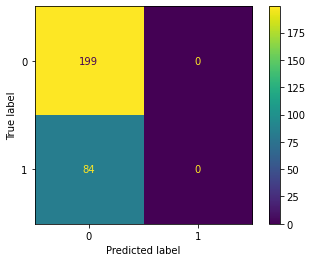

In [8]:
print("Baseline Model")
ConfusionMatrixDisplay.from_estimator(baseline_model, X_test, y_test)

Logistic Regression Model


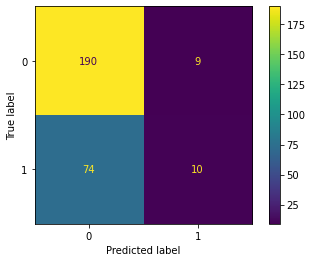

In [9]:
print("Logistic Regression Model")
ConfusionMatrixDisplay.from_estimator(lr_model, X_test, y_test)

XGBoost Model


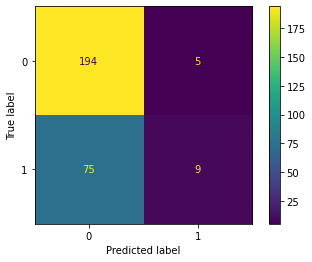

In [10]:
print("XGBoost Model")
ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test)